In [51]:
import cartopy.crs as ccrs
import iris
from IPython.display import HTML, clear_output
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from remake2 import load_remake

In [6]:
cd /home/users/mmuetz/projects/mcs_prime/ctrl/stoch_trig_remakefiles/

/home/users/mmuetz/projects/mcs_prime/ctrl/stoch_trig_remakefiles


In [16]:
rmk = load_remake('N216_sims_process.py')

2024-09-04 19:39:14.556 | DEBUG    | remake2.remake_base:load_rules:56 - Loading rules
2024-09-04 19:39:14.572 | DEBUG    | remake2.remake_base:load_rules:78 - inserting rules
2024-09-04 19:39:14.820 | DEBUG    | remake2.remake_base:finalize:170 - getting task status
2024-09-04 19:39:14.838 | DEBUG    | remake2.remake_base:load_rules:91 - Loaded rules


In [19]:
actasks = rmk.tasks[:3]

In [30]:
expts_acs = {e: xr.open_dataset(t.outputs['pflux_autocorr']) 
             for t, e in [(t, t.kwargs['expt']) for t in actasks]}

In [31]:
imerg_ac = xr.load_dataset(rmk.tasks[3].outputs['imerg_autocorr'])

Text(0.5, 1.0, 'stochMCSP - vanillaMCSP')

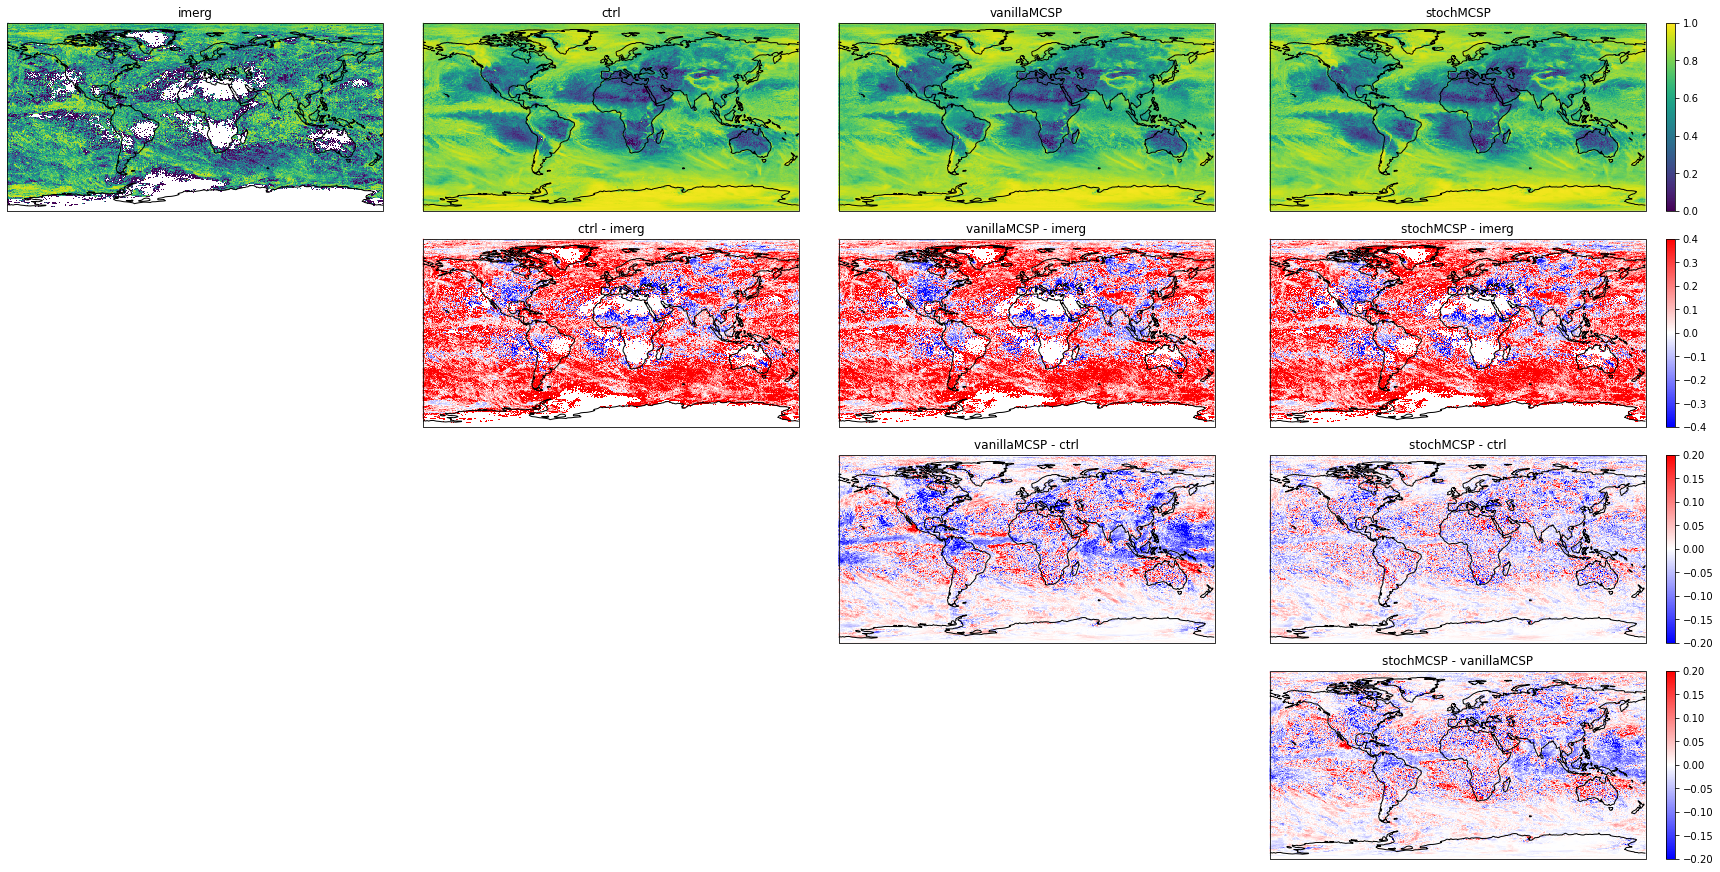

In [67]:
fig, axes = plt.subplots(4, 4, subplot_kw={'projection': ccrs.PlateCarree()}, layout='constrained')
fig.set_size_inches((24, 12))
im = axes[0, 0].pcolormesh(imerg_ac.longitude, imerg_ac.latitude, imerg_ac.imerg_autocorr, vmin=0, vmax=1)
# plt.colorbar(im, ax=axes[0])
axes[0, 0].coastlines()

for ax, expt_ac in zip(axes[0, 1:], expts_acs.values()):
    im = ax.pcolormesh(expt_ac.longitude, expt_ac.latitude, expt_ac.pflux_autocorr.mean(dim='ens_mem'), vmin=0, vmax=1)
    # plt.colorbar(im, ax=ax)
    ax.coastlines()

plt.colorbar(im, ax=axes[0, -1])
    
for ax, expt_ac in zip(axes[1, 1:], expts_acs.values()):
    im = ax.pcolormesh(expt_ac.longitude, expt_ac.latitude, expt_ac.pflux_autocorr.mean(dim='ens_mem') - imerg_ac.imerg_autocorr, vmin=-.4, vmax=.4, cmap='bwr')
    # plt.colorbar(im, ax=ax)
    ax.coastlines()
    
plt.colorbar(im, ax=axes[1, -1])

for ax, expt_ac in zip(axes[2, 2:], list(expts_acs.values())[1:]):
    im = ax.pcolormesh(expt_ac.longitude, expt_ac.latitude, expt_ac.pflux_autocorr.mean(dim='ens_mem') - expts_acs['ctrl'].pflux_autocorr.mean(dim='ens_mem'), vmin=-.2, vmax=.2, cmap='bwr')
    # plt.colorbar(im, ax=ax)
    ax.coastlines()
    
plt.colorbar(im, ax=axes[2, -1])


ax = axes[3, 3]
im = ax.pcolormesh(expt_ac.longitude, expt_ac.latitude, expts_acs['vanillaMCSP'].pflux_autocorr.mean(dim='ens_mem') - expts_acs['stochMCSP'].pflux_autocorr.mean(dim='ens_mem'), vmin=-.2, vmax=.2, cmap='bwr')
# plt.colorbar(im, ax=ax)
ax.coastlines()

plt.colorbar(im, ax=ax)

for ax in axes[np.tril_indices(4, -1)].flatten():
    ax.axis('off')

axes[0, 0].set_title('imerg')
for ax, expt in zip(axes[0, 1:], expts_acs):
    ax.set_title(expt)

for ax, expt in zip(axes[1, 1:], expts_acs):
    ax.set_title(f'{expt} - imerg')
    
for ax, expt in zip(axes[2, 2:], list(expts_acs.keys())[1:]):
    ax.set_title(f'{expt} - ctrl')

axes[3, 3].set_title('stochMCSP - vanillaMCSP')

In [63]:
a = np.arange(16).reshape(4, 4) + 1
a[np.tril_indices(4, -1)] = 0
a

array([[ 1,  2,  3,  4],
       [ 0,  6,  7,  8],
       [ 0,  0, 11, 12],
       [ 0,  0,  0, 16]])